In [11]:
import os
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import msaf
from tqdm import tqdm

sns.set(style="darkgrid")

In [12]:
def extract_features(filepath):
    y, sr = librosa.load(filepath, sr=None)
    
    features = {}
    
    features["duration"] = librosa.get_duration(y=y, sr=sr)
    
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    features["tempo"] = float(np.mean(tempo))
    
    features["rms_mean"] = np.mean(librosa.feature.rms(y=y))
    features["spectral_centroid_mean"] = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    features["spectral_bandwidth_mean"] = np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr))
    features["spectral_rolloff_mean"] = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
    features["zcr_mean"] = np.mean(librosa.feature.zero_crossing_rate(y))
    
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    features["chroma_mean"] = np.mean(chroma)
    features["chroma_std"] = np.std(chroma)
    
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    for i in range(13):
        features[f"mfcc_{i+1}_mean"] = np.mean(mfcc[i])
        features[f"mfcc_{i+1}_std"] = np.std(mfcc[i])
    
    return features

In [13]:
def structural_features(filepath):
    boundaries, labels = msaf.process(filepath, boundaries_id="foote")
    
    segment_lengths = np.diff(boundaries)
    labels_array = np.array(labels)
    non_negative_labels = labels_array[labels_array != -1]
    unique_labels = set(labels_array)
    
    entropy = 0
    for l in unique_labels:
        if l != -1:
            p = list(labels_array).count(l) / len(labels_array)
            entropy += -p * np.log2(p)
    
    return {
        "num_segments": len(segment_lengths),
        "avg_segment_length": np.mean(segment_lengths),
        "segment_length_std": np.std(segment_lengths),
        "num_structured_sections": len(non_negative_labels),
        "structure_ratio": len(non_negative_labels) / len(labels_array),
        "unique_sections": len(unique_labels) - (1 if -1 in unique_labels else 0),
        "label_entropy": entropy
    }

In [14]:
base_folder = "song_mp3"
rows = []

CHECKPOINT = "checkpoint.csv"

# Load already-processed songs if checkpoint exists
if os.path.exists(CHECKPOINT):
    df_done = pd.read_csv(CHECKPOINT)
    done_files = set(df_done["song"].tolist())
    rows = df_done.to_dict("records")
    print(f"Resuming — {len(done_files)} songs already done")
else:
    done_files = set()
    rows = []

all_files = [
    (os.path.join(base_folder, d, f), f, d)
    for d in os.listdir(base_folder)
    if os.path.isdir(os.path.join(base_folder, d))
    for f in os.listdir(os.path.join(base_folder, d))
    if f.endswith(".mp3")
]

for filepath, file, decade in tqdm(all_files, desc="Processing songs"):
    if file in done_files:
        continue  # skip already processed
    try:
        audio_feats = extract_features(filepath)
        struct_feats = structural_features(filepath)
        combined = {**audio_feats, **struct_feats}
        combined["song"] = file
        combined["decade"] = decade
        rows.append(combined)

        # Save after every song
        pd.DataFrame(rows).to_csv(CHECKPOINT, index=False)
    except Exception as e:
        print(f"Skipping {file}: {e}")

df_all = pd.DataFrame(rows)

df_all.head()

Processing songs:   0%|          | 0/140 [00:00<?, ?it/s]

Processing songs: 100%|██████████| 140/140 [43:51<00:00, 18.79s/it]


,duration,tempo,rms_mean,spectral_centroid_mean,spectral_bandwidth_mean,spectral_rolloff_mean,zcr_mean,chroma_mean,chroma_std,mfcc_1_mean,...,mfcc_13_std,num_segments,avg_segment_length,segment_length_std,num_structured_sections,structure_ratio,unique_sections,label_entropy,song,decade
0,233.662404,90.666118,0.101435,3532.023367,3400.499152,7283.451094,0.092805,0.445509,0.287692,-149.246017,...,7.479587,18,12.981245,7.642225,2,0.111111,1,0.352214,NA-I'm So Excited.mp3.mp3,1980
1,244.831202,107.666016,0.200271,3032.832943,3191.841067,6020.687270,0.073226,0.485379,0.295696,-118.664230,...,7.899753,12,20.402600,8.816376,1,0.083333,1,0.298747,NA-Upside Down.mp3.mp3,1980
2,207.818594,126.048018,0.068001,3944.613535,3428.667403,7581.554409,0.116745,0.450424,0.287771,-176.661972,...,7.272492,10,20.781859,8.745345,1,0.100000,1,0.332193,John Mellencamp - Hurts So Good (Official Musi...,1980
3,268.515556,93.963068,0.168164,1954.540437,2640.015986,3519.936235,0.045724,0.373673,0.299095,-172.673889,...,7.773252,11,24.410505,13.974496,1,0.090909,1,0.314494,NA-Endless Love.mp3.mp3,1980
4,215.388299,90.666118,0.108002,2075.257282,2769.695049,4295.092338,0.041444,0.406748,0.307362,-217.683807,...,9.045420,7,30.769757,17.791930,1,0.142857,1,0.401051,"NA-Patti Austin feat. James Ingram - Baby, Com...",1980


In [15]:
df_decade = df_all.groupby("decade").mean(numeric_only=True).reset_index()

df_decade

,decade,duration,tempo,rms_mean,spectral_centroid_mean,spectral_bandwidth_mean,spectral_rolloff_mean,zcr_mean,chroma_mean,chroma_std,...,mfcc_12_std,mfcc_13_mean,mfcc_13_std,num_segments,avg_segment_length,segment_length_std,num_structured_sections,structure_ratio,unique_sections,label_entropy
0,1950,157.616980,120.835955,0.144892,2368.127146,2632.848939,4689.855945,0.058075,0.418208,0.301348,...,8.761142,0.352579,8.275642,8.70,19.210485,11.187845,1.30,0.162065,1.0,0.402736
1,1960,174.578068,114.359147,0.124614,2327.502413,2619.544066,4698.563868,0.057439,0.412093,0.297003,...,8.558359,0.270328,8.530753,9.65,19.183887,10.945858,1.25,0.143228,1.0,0.384967
2,1970,237.016418,118.757367,0.133811,2664.052335,3057.899671,5507.703621,0.061350,0.437565,0.291705,...,8.904911,-2.384961,8.132154,12.15,20.071825,10.786732,1.45,0.132406,1.0,0.362065
3,1980,239.864604,121.768867,0.118773,2924.124315,3098.831801,5952.487694,0.071325,0.441141,0.295571,...,8.709694,0.711931,8.077276,12.85,19.460362,9.990762,1.40,0.109555,1.0,0.343592
4,1990,250.082395,127.174124,0.156839,2928.482285,3330.198723,6413.708832,0.060417,0.462454,0.296750,...,9.792910,0.601070,8.752057,12.75,20.165247,10.413054,1.45,0.116134,1.0,0.351101
5,2000,230.058087,125.114078,0.200864,2866.117222,3252.457187,6156.557664,0.062574,0.439418,0.291863,...,9.088183,1.000840,8.139287,12.60,18.959466,9.953649,1.20,0.097553,1.0,0.321263
6,2010,235.124100,122.015356,0.205080,2587.008091,2992.340312,5438.843872,0.055560,0.434568,0.302093,...,10.684845,0.754893,9.780210,11.80,20.599247,10.838508,1.25,0.113827,1.0,0.340025


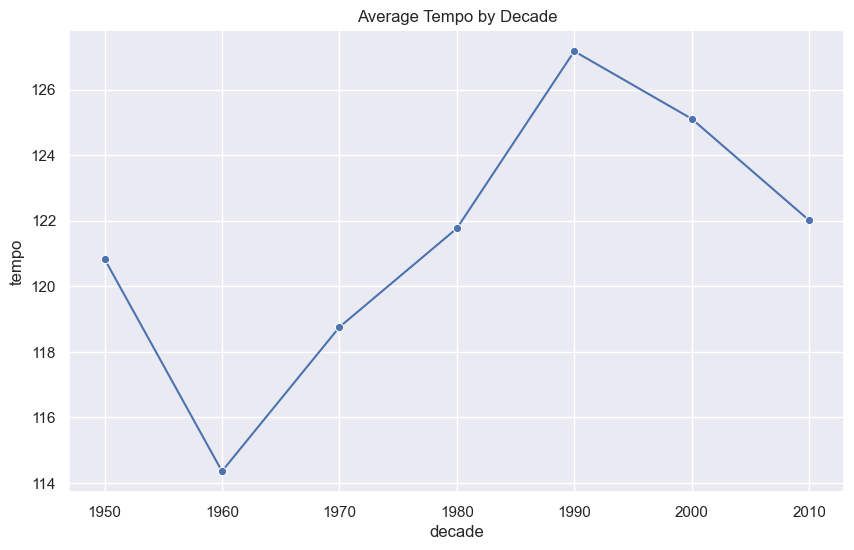

In [16]:
plt.figure(figsize=(10,6))
sns.lineplot(x="decade", y="tempo", data=df_decade, marker="o")
plt.title("Average Tempo by Decade")
plt.savefig("docs/plots/tempo_trend.png", dpi=300, bbox_inches="tight")
plt.show()

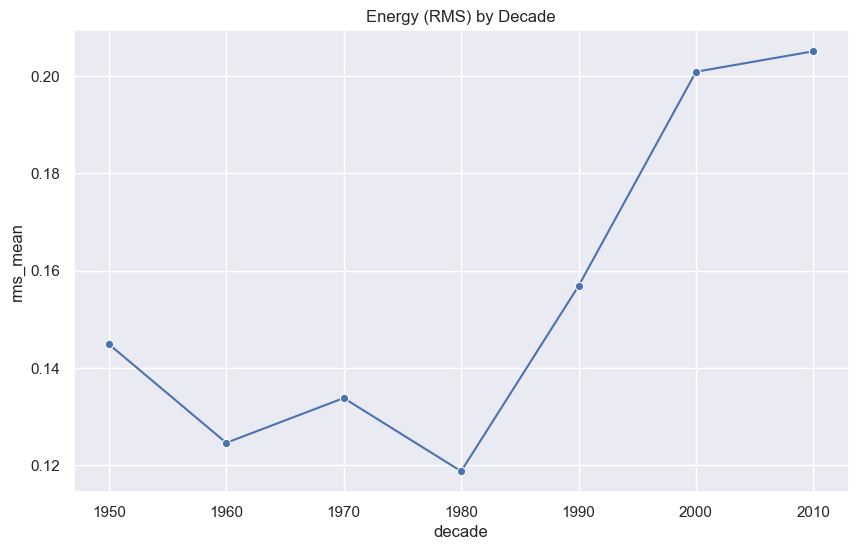

In [17]:
plt.figure(figsize=(10,6))
sns.lineplot(x="decade", y="rms_mean", data=df_decade, marker="o")
plt.title("Energy (RMS) by Decade")
plt.savefig("docs/plots/energy_trend.png", dpi=300, bbox_inches="tight")
plt.show()

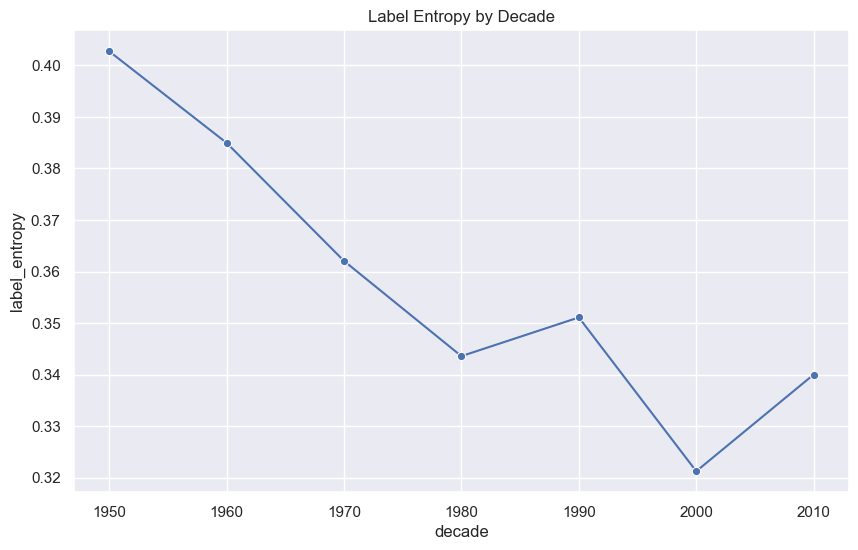

In [18]:
plt.figure(figsize=(10,6))
sns.lineplot(x="decade", y="label_entropy", data=df_decade, marker="o")
plt.title("Label Entropy by Decade")
plt.savefig("docs/plots/label_entropy_trend.png", dpi=300, bbox_inches="tight")
plt.show()

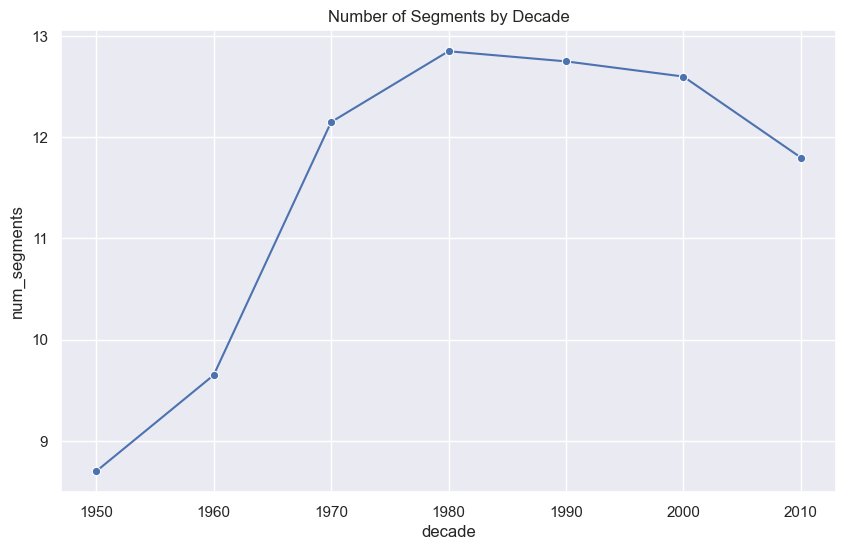

In [19]:
plt.figure(figsize=(10,6))
sns.lineplot(x="decade", y="num_segments", data=df_decade, marker="o")
plt.title("Number of Segments by Decade")
plt.savefig("docs/plots/num_segments_trend.png", dpi=300, bbox_inches="tight")
plt.show()

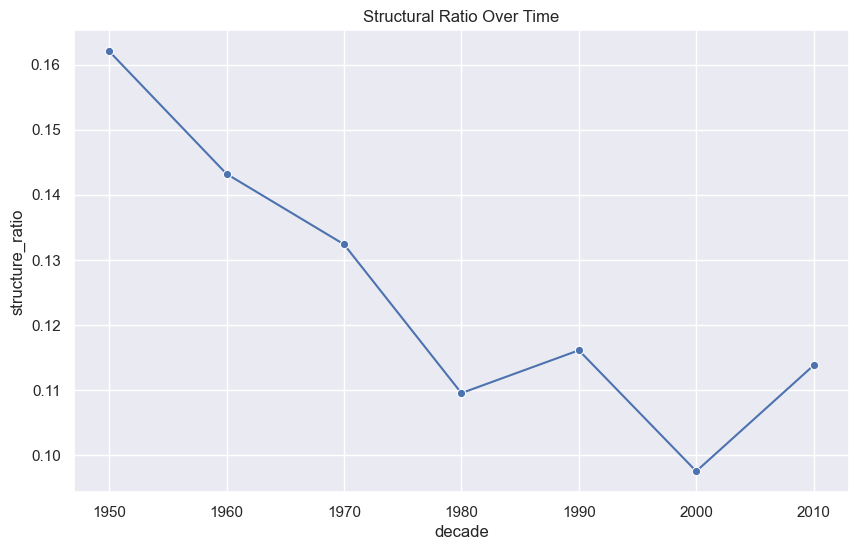

In [20]:
plt.figure(figsize=(10,6))
sns.lineplot(x="decade", y="structure_ratio", data=df_decade, marker="o")
plt.title("Structural Ratio Over Time")
plt.savefig("docs/plots/structure_ratio_trend.png", dpi=300, bbox_inches="tight")
plt.show()

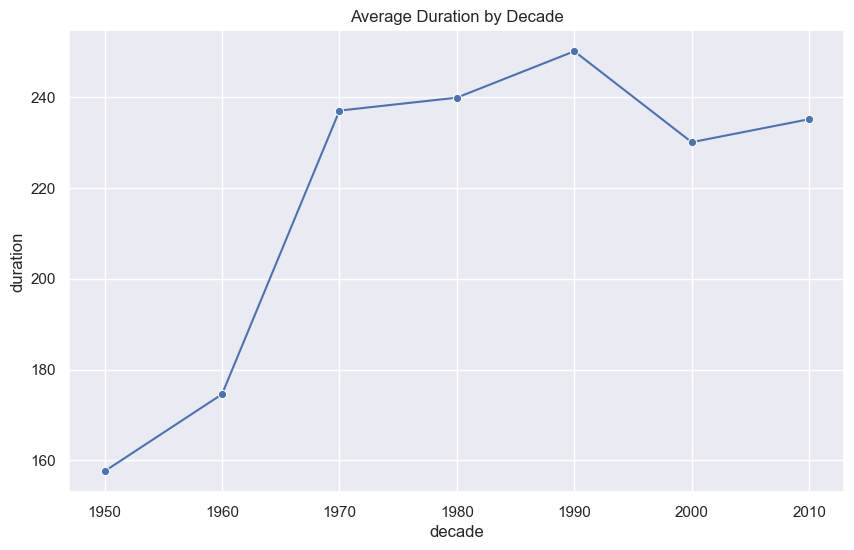

In [21]:
plt.figure(figsize=(10,6))
sns.lineplot(x="decade", y="duration", data=df_decade, marker="o")
plt.title("Average Duration by Decade")
plt.savefig("docs/plots/duration_trend.png", dpi=300, bbox_inches="tight")
plt.show()

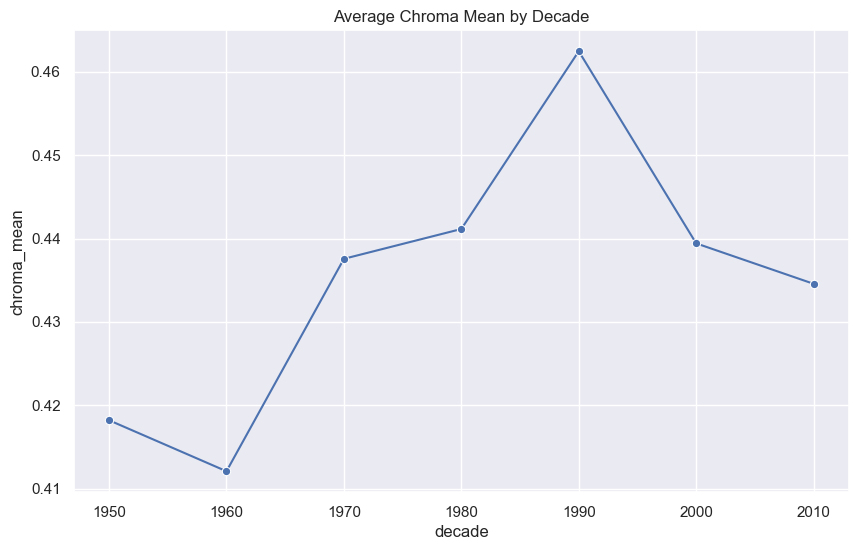

In [22]:
plt.figure(figsize=(10,6))
sns.lineplot(x="decade", y="chroma_mean", data=df_decade, marker="o")
plt.title("Average Chroma Mean by Decade")
plt.savefig("docs/plots/chroma_mean_trend.png", dpi=300, bbox_inches="tight")
plt.show()

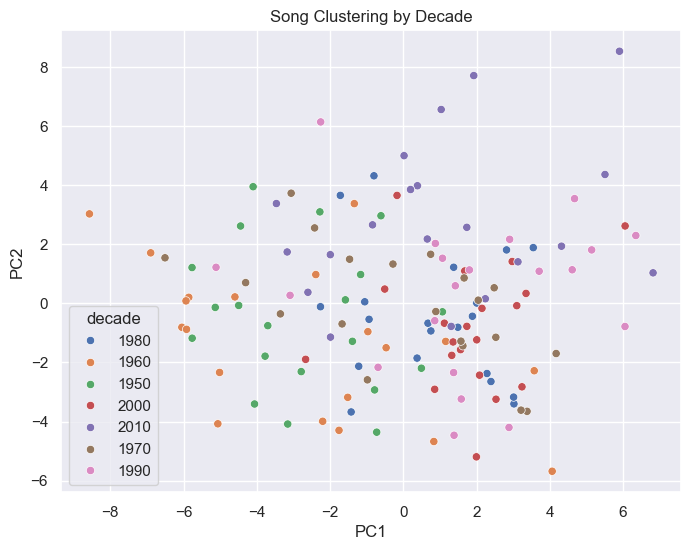

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

features_for_pca = df_all.drop(columns=["song","decade"])
scaler = StandardScaler()
scaled = scaler.fit_transform(features_for_pca)

pca = PCA(n_components=2)
components = pca.fit_transform(scaled)

df_all["PC1"] = components[:,0]
df_all["PC2"] = components[:,1]

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_all, x="PC1", y="PC2", hue="decade")
plt.title("Song Clustering by Decade")
plt.show()

In [24]:
from sklearn.linear_model import LinearRegression
import numpy as np

X = np.arange(len(df_decade)).reshape(-1,1)
y = df_decade["label_entropy"].values

model = LinearRegression().fit(X,y)
print("Entropy trend slope:", model.coef_[0])

Entropy trend slope: -0.011660794317051986


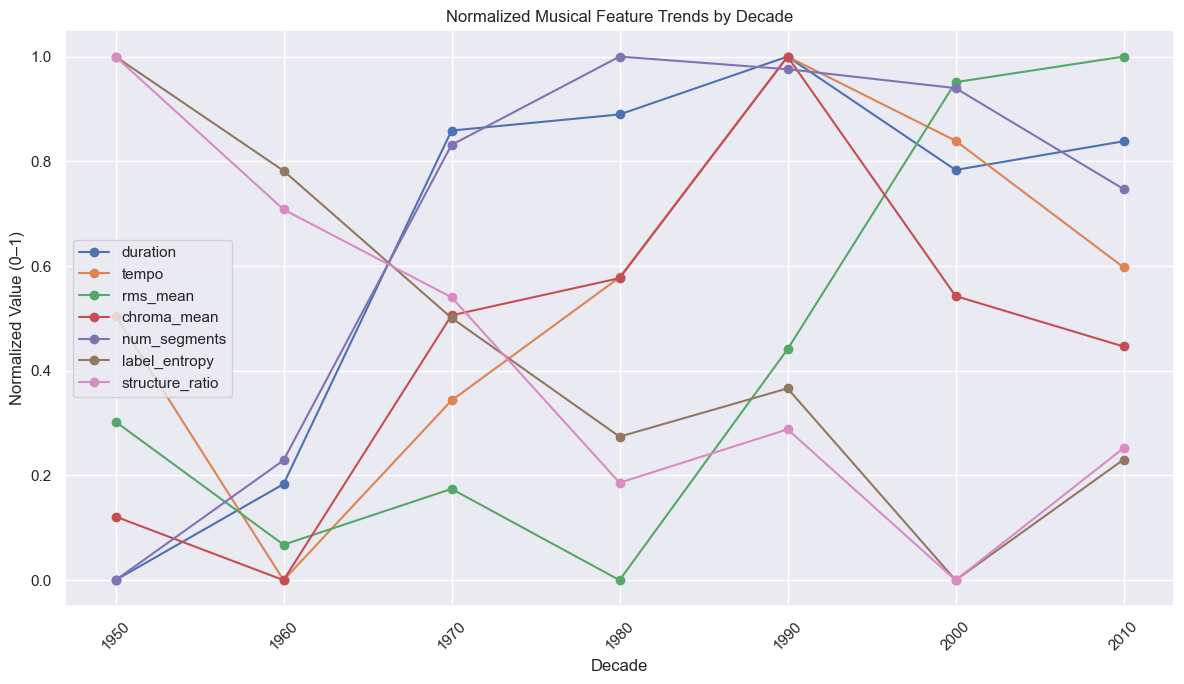

In [25]:
from sklearn.preprocessing import MinMaxScaler

features_to_plot = [
    "duration",
    "tempo",
    "rms_mean",
    "chroma_mean",
    "num_segments",
    "label_entropy",
    "structure_ratio"
]

# Normalize to 0–1 for fair comparison
scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(df_decade[features_to_plot])

scaled_df = pd.DataFrame(
    scaled_values,
    columns=features_to_plot
)

scaled_df["decade"] = df_decade["decade"]

# Plot
plt.figure(figsize=(12,7))

for feature in features_to_plot:
    plt.plot(
        scaled_df["decade"],
        scaled_df[feature],
        marker="o",
        label=feature
    )

plt.title("Normalized Musical Feature Trends by Decade")
plt.xlabel("Decade")
plt.ylabel("Normalized Value (0–1)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()